In [1]:
import tables
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2


In [2]:
a = tables.open_file("/data/cta/users-ifae/summer_students/agl/scripts/chis.h5")

In [3]:
a.root.chis2.results

/chis2/results (Table(np.int64(3505),)) np.str_('Combined chi2 results')
  description := {
  "check_index": Int32Col(shape=(), dflt=np.int32(0), pos=0),
  "chi2": Float64Col(shape=(), dflt=np.float64(0.0), pos=1),
  "dof": Int32Col(shape=(), dflt=np.int32(0), pos=2),
  "run": Int32Col(shape=(), dflt=np.int32(0), pos=3)}
  byteorder := 'little'
  chunkshape := (np.int64(3276),)

[]

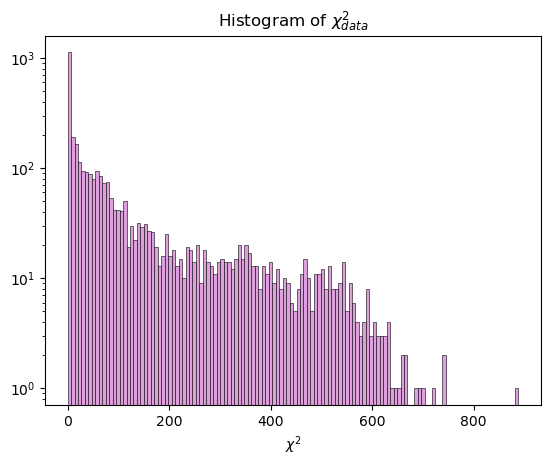

In [4]:
chi2_data = a.root.chis2.results.col('chi2')

plt.hist(chi2_data, bins=130, color='plum',  edgecolor='black', linewidth=0.4)
plt.xlabel(r'$ \chi ^2$')
plt.title(r'Histogram of $ \chi ^2_{ data}$')
plt.yscale('log')
plt.plot()



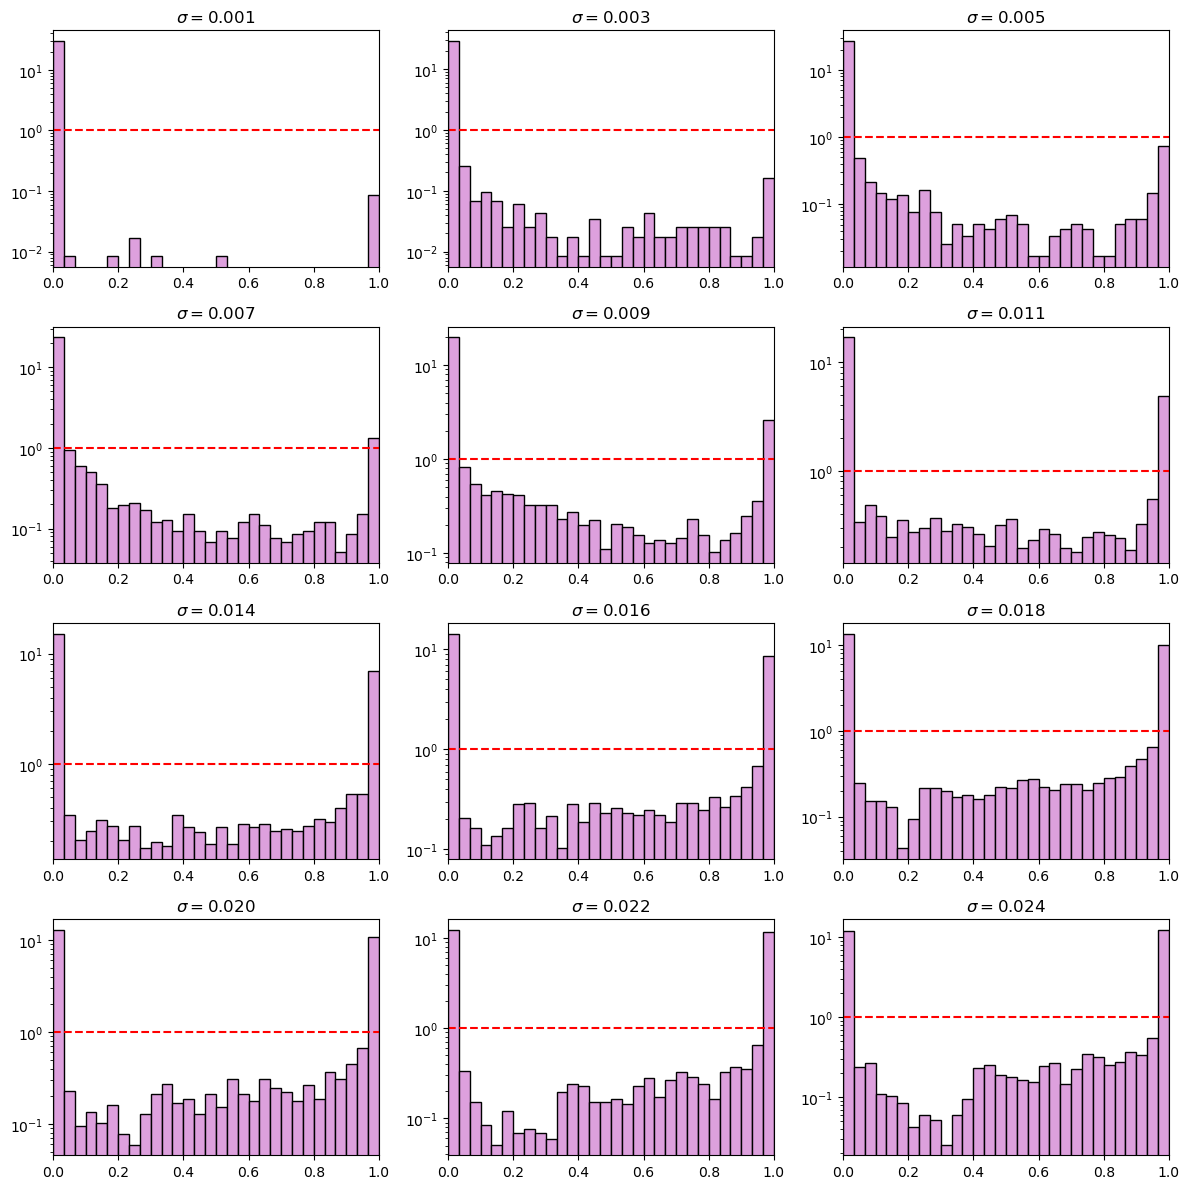

In [16]:
import math

sigma_pixels = np.linspace(0.001, 0.024, 12)

ncols = 3
nrows = math.ceil(len(sigma_pixels) / ncols)

fig, ax = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))
ax = ax.ravel()

sigma_pixel_o = 28*np.tan(np.radians(0.05))
dof = a.root.chis2.results.col('dof')

for i, sigma in enumerate(sigma_pixels):

    chi2_data_new = (sigma_pixel_o / sigma)**2 * chi2_data
    p_values = 1 - chi2.cdf(chi2_data_new, dof)

    ax[i].hist(
        p_values,
        bins=30,
        range=(0,1),
        density=True,
        color='plum',
        edgecolor='black'
    )

    ax[i].axhline(1, color='red', ls='--')
    ax[i].set_yscale('log')
    ax[i].set_title(rf'$\sigma={sigma:.3f}$')
    ax[i].set_xlim(0,1)

# Elimina los ejes vacíos si sobran
for j in range(len(sigma_pixels), len(ax)):
    fig.delaxes(ax[j])

plt.tight_layout()
plt.show()

Text(0.5, 0, '$\\chi^2/\\nu$')

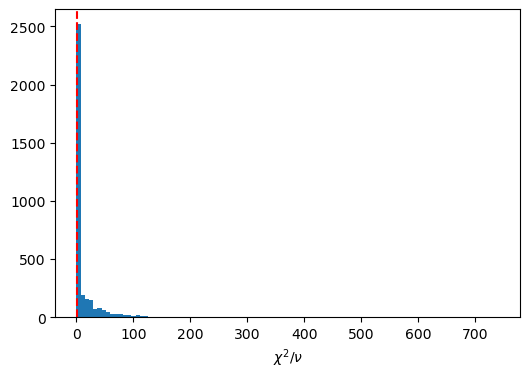

In [17]:
plt.figure(figsize=(6,4))
plt.hist(chi2_data/dof, bins=100)
plt.axvline(1, color='r', ls='--')
plt.xlabel(r'$\chi^2/\nu$')